# Temporal asynchrony between modalities

## Guiding question
Are there different response latencies between EEG, facial and EDA signals that generate desynchronization patterns that mask relationships between the modalities?

## Methodology
In order to find the latencies between the modalities, we analyzed the relation between the signals considering as a stimulus the start of the math task and also the start of the video watching task. We plotted the signals around the stimulus and looked for patterns of desynchronization. We also calculated the cross-correlation between the signals to find the time lag that maximizes their correlation.

**Part 1: Plotting the signals across time**

First, we plotted the entire time series of the EDA, alpha brainwaves and happiness facial expression probability for the first subject. We marked the task breaks, and this was done in order to visually inspect the signals at a large scale.

After that, we plotted the mentioned signals around the start of the math task and the start of the video watching task. We looked for patterns of desynchronization, such as peaks or troughs in the signals that occur at different times for each modality. We also looked for patterns of synchronization, such as peaks or troughs that occur at the same time for each modality. We focused the graphs on showing information of 3 participants in order to contrast the patterns found.

**Part 2: Calculating the cross-correlation between the signals and lag**

In this part, we calculated the cross-correlation between the EDA and alpha brainwaves, EDA and happiness facial expression probability, and alpha brainwaves and happiness facial expression probability for each participant. We then found the time lag that maximizes the correlation between each pair of signals. This was done to quantify the temporal asynchrony between the modalities and to see if there are consistent patterns across participants.

**Part 3: Full time-series vs per-task correlation analysis**

For this part, we calculated the correlation between the signals using the full time-series data and then compared it to the correlation calculated using only the data separated by task. This was done to see if the temporal asynchrony between the modalities is more pronounced when looking at the full time-series data compared to when looking at the data from each task separately. We also looked for patterns of desynchronization in the full time-series data and compared them to the patterns found in the per-task data.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data set
df = pd.read_csv('../NPFC-Test_Database_V2.csv')
df.columns

Index(['Subject_ID', 'Timestamp', 'Test_Time', 'Task_Num', 'Task_Time',
       'Task_Type', 'Frame', 'Task_Frame', 'Selfreport_valence',
       'Selfreport_arousal', 'Selfreport_focus', 'Face_Detection',
       'resmasknet_anger', 'resmasknet_disgust', 'resmasknet_fear',
       'resmasknet_happiness', 'resmasknet_sadness', 'resmasknet_surprise',
       'resmasknet_neutral', 'svm_anger', 'svm_disgust', 'svm_fear',
       'svm_happiness', 'svm_sadness', 'svm_surprise', 'svm_neutral',
       'Temperature', 'EDA', 'BVP', 'HeadBandOn', 'Delta_TP9', 'Delta_AF7',
       'Delta_AF8', 'Delta_TP10', 'Theta_TP9', 'Theta_AF7', 'Theta_AF8',
       'Theta_TP10', 'Alpha_TP9', 'Alpha_AF7', 'Alpha_AF8', 'Alpha_TP10',
       'Beta_TP9', 'Beta_AF7', 'Beta_AF8', 'Beta_TP10', 'Gamma_TP9',
       'Gamma_AF7', 'Gamma_AF8', 'Gamma_TP10', 'RAW_TP9', 'RAW_AF7', 'RAW_AF8',
       'RAW_TP10', 'Age', 'Gender', 'Dominant_Hand', 'Average_Sleep',
       'Sleep_Last_Night', 'Perceived_Tiredness', 'Perceived_Stress',
 

# Part 1: Plotting the signals across time

We will start by plotting the entire time series of the EDA, alpha brainwaves and happiness facial expression probability for the first subject. We will mark the task breaks, and this will be done in order to visually inspect the signals at a large scale.

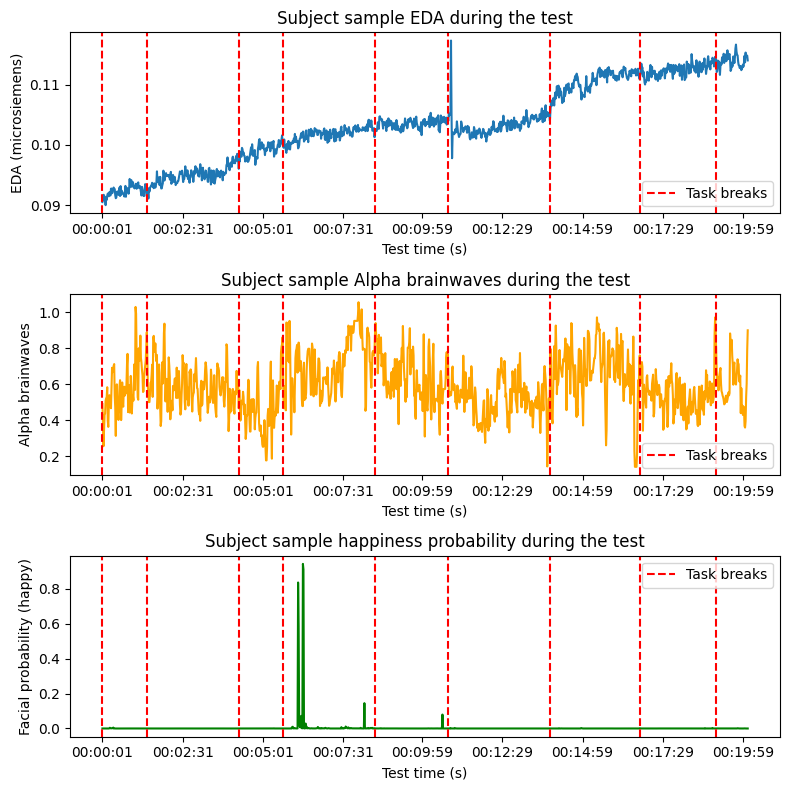

In [334]:
subject_ids = df["Subject_ID"].unique()

fig, axes = plt.subplots(3, 1, figsize=(8, 8))

[ax1, ax2, ax3] = axes

subject_data = df[df["Subject_ID"] == subject_ids[0]]
x = subject_data['Test_Time']
y_EDA = subject_data["EDA"]
y_Alpha = subject_data[['Alpha_TP9', 'Alpha_AF7', 'Alpha_AF8', 'Alpha_TP10']].mean(axis=1)
y_Emotion = subject_data["resmasknet_happiness"]

ax1.set_xlabel("Test time (s)")
ax1.set_ylabel("EDA (microsiemens)")
ax1.plot(x, y_EDA)

ax2.set_xlabel("Test time (s)")
ax2.set_ylabel('Alpha brainwaves')
ax2.plot(x, y_Alpha, color="orange")

ax3.set_xlabel("Test time (s)")
ax3.set_ylabel('Facial probability (happy)')
ax3.plot(x, y_Emotion, color="green")

prev_task_num = 0
lines1, lines2, lines3 = [], [], []
for index, row in subject_data.iterrows():
  if int(row["Task_Num"]) > prev_task_num:
    prev_task_num = int(row["Task_Num"])
    lines1.append(ax1.axvline(x=row["Test_Time"], color='r', linestyle='--'))
    lines2.append(ax2.axvline(x=row["Test_Time"], color='r', linestyle='--'))
    lines3.append(ax3.axvline(x=row["Test_Time"], color='r', linestyle='--'))

ax1.set_title("Subject sample EDA during the test")
ax2.set_title("Subject sample Alpha brainwaves during the test")
ax3.set_title("Subject sample happiness probability during the test")

ax1.set_xticks(x[::150])
ax2.set_xticks(x[::150])
ax3.set_xticks(x[::150])

ax1.legend(lines1, ["Task breaks"])
ax2.legend(lines2, ["Task breaks"])
ax3.legend(lines3, ["Task breaks"])

plt.tight_layout()

Now we will select the first 3 participants and plot the mentioned signals around the start of the math task and the start of the video watching task in order to look for patterns of desynchronization.

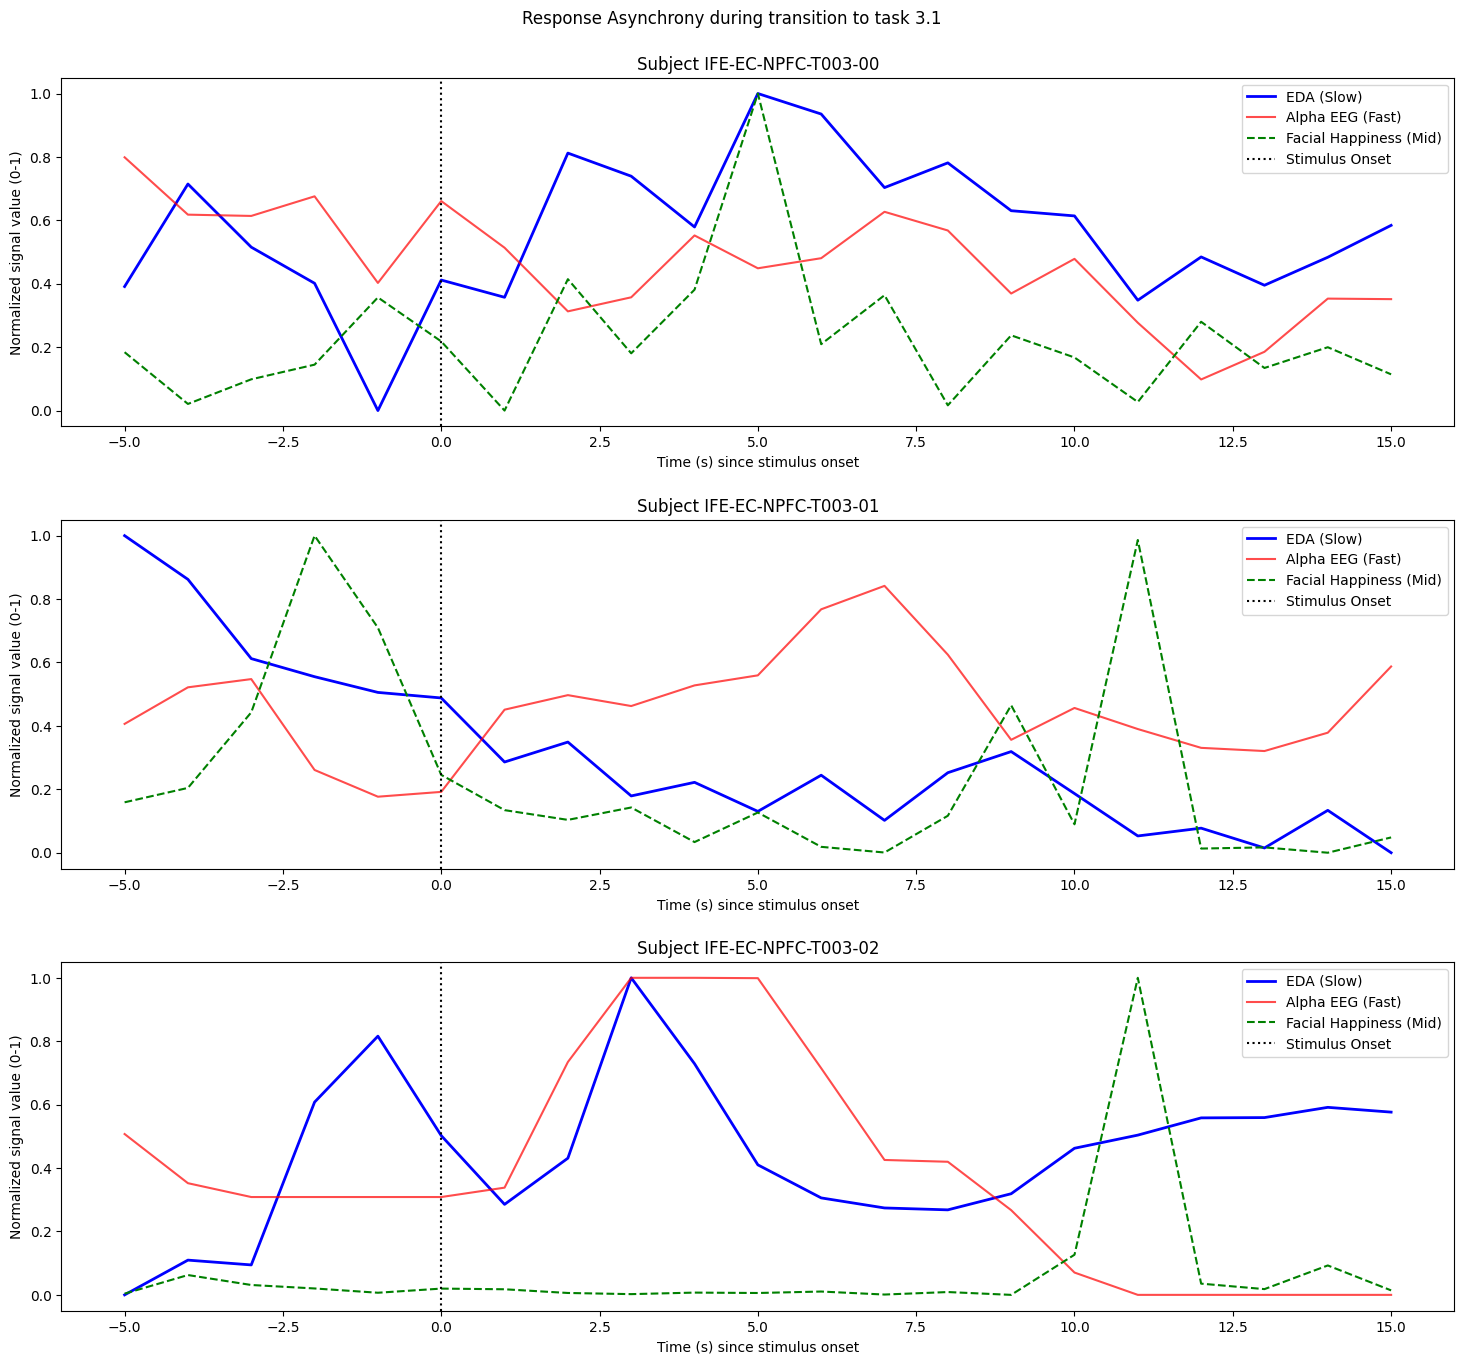

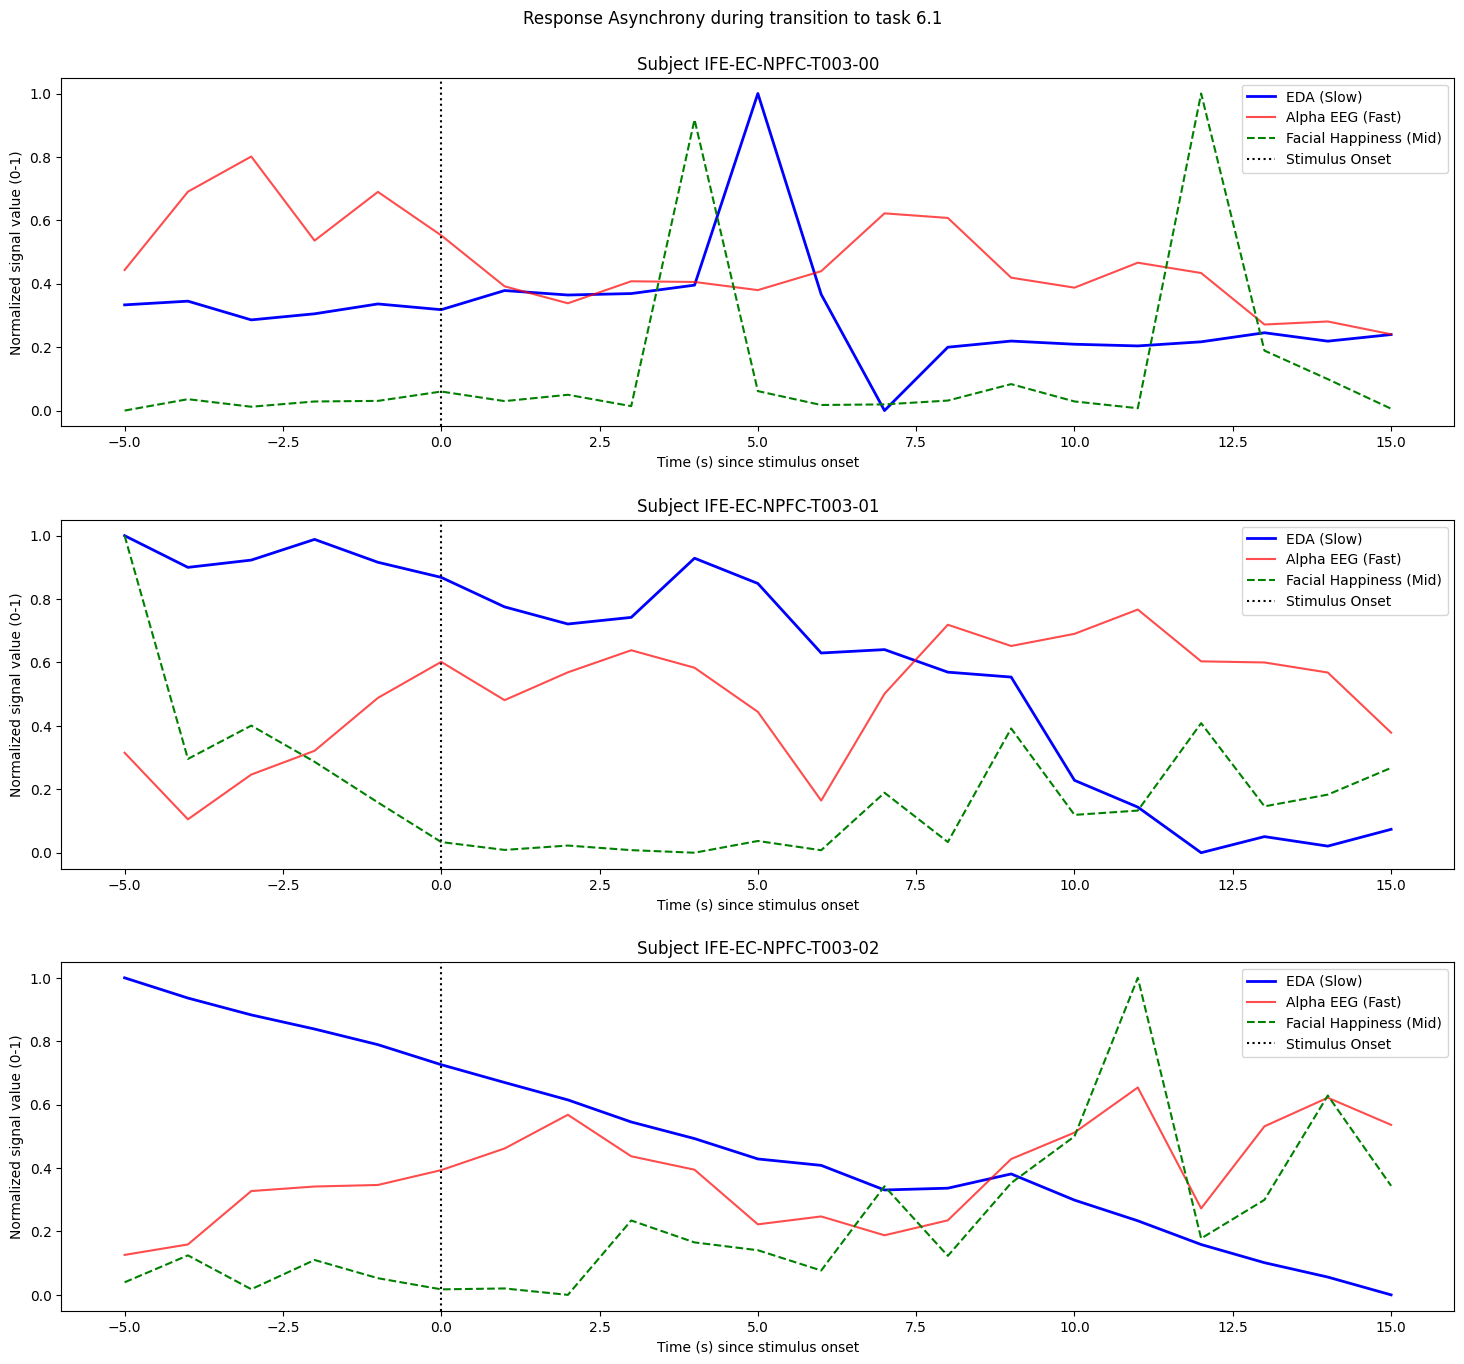

In [335]:
# 1. Selection
subjects = df['Subject_ID'].unique()[:3]

def time_to_seconds(t_str):
    try:
        h, m, s = map(int, t_str.split(':'))
    except:
        m, s = map(int, t_str.split(':'))
        h = 0
    return h * 3600 + m * 60 + s

def time_since_timestamp(timestamp):
    return lambda seconds: seconds - timestamp

def plot_task_data(task_id):

    df['Total_Seconds'] = df['Test_Time'].apply(time_to_seconds)

    fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=False)

    for i, sub_id in enumerate(subjects):
        # Filter data
        sub_df = df[df['Subject_ID'] == sub_id]
        
        # Identify stimulus start (Test_Time)
        try:
            stim_time = sub_df[sub_df['Task_Num'] == task_id]['Total_Seconds'].iloc[0]
            # Get window: 5s before, 15s after
            plot_data = sub_df[(sub_df['Total_Seconds'] >= stim_time - 5) & 
                            (sub_df['Total_Seconds'] <= stim_time + 15)].copy()
            
            plot_data['Time_Since_Task'] = df["Total_Seconds"].apply(time_since_timestamp(stim_time))
            
            # 2. Normalize signals (0-1) for visual comparison
            for col in ['EDA', 'Alpha_TP9', 'Alpha_AF7', 'Alpha_AF8', 'Alpha_TP10', 'resmasknet_happiness']:
                plot_data[col] = (plot_data[col] - plot_data[col].min()) / (plot_data[col].max() - plot_data[col].min())
            
            # 3. Plotting
            ax = axes[i]
            ax.plot(plot_data['Time_Since_Task'], plot_data['EDA'], label='EDA (Slow)', color='blue', linewidth=2)
            ax.plot(plot_data['Time_Since_Task'], plot_data[['Alpha_TP9', 'Alpha_AF7', 'Alpha_AF8', 'Alpha_TP10']].mean(axis=1), label='Alpha EEG (Fast)', color='red', alpha=0.7)
            ax.plot(plot_data['Time_Since_Task'], plot_data['resmasknet_happiness'], label='Facial Happiness (Mid)', color='green', linestyle='--')
            
            ax.axvline(x=0, color='black', linestyle=':', label='Stimulus Onset')
            ax.set_title(f'Subject {sub_id}')
            ax.legend()
            ax.set_xlabel("Time (s) since stimulus onset")
            ax.set_ylabel("Normalized signal value (0-1)")
            
        except IndexError:
            print(f"Task {task_id} not found for Subject {sub_id}")

    plt.suptitle(f"Response Asynchrony during transition to task {task_id}")
    plt.tight_layout(pad=2)
    plt.show()

plot_task_data(3.1) # Math task
plot_task_data(6.1) # Video task

After visually inspecting the graphs, we can observe that EDA usually peaks around 5 seconds after the stimulus onset (start of the task). We can also observe that the alpha brainwaves do change slightly right after the stimulus onset, but the resolution of the changes (1Hz) makes it really hard to see clear patterns of activation in those moments. Finally, the happiness facial expression probability also seams to peak alongside the EDA between 3 to 10 seconds after the task starts. 

However, in order to get a better understanding of these latencies, we will perform a more rigorous analysis by calculating lagged correlations between the signals.

# Part 2: Calculating the cross-correlation between the signals and lag

Here we will calculate the cross-correlation between the EDA and alpha brainwaves, EDA and happiness facial expression probability, and alpha brainwaves and happiness facial expression probability for each participant with different amounts of lag, and then find the lag that maximizes the correlation between each pair of signals. These signals were selected because there has been research made that shows the expected latency each of them should have in response to a stimulus.

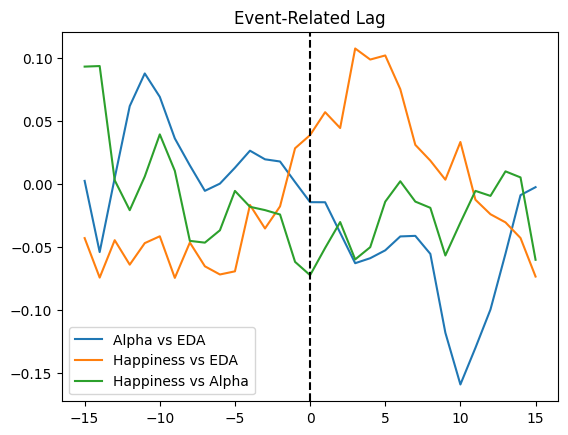

Optimal Lag (Alpha vs EDA): 10s: r=-0.1588312752947687
Optimal Lag (Happiness vs EDA): 3s: r=0.10732413065276084
Optimal Lag (Happiness vs Alpha): -14s: r=0.0934044535381503


In [ ]:
def calculate_event_lagged_corr(df, col1, col2, task_id=3.1, max_lag=10):
    lags = np.arange(-max_lag, max_lag + 1)
    all_event_corrs = []
    
    # Iterate through subjects
    for sub_id in df['Subject_ID'].unique():
        sub_df = df[df['Subject_ID'] == sub_id].copy()
        
        # 1. Find the task transitions
        try:
            task_idx = sub_df[sub_df['Task_Num'] == task_id].index[0]
            # 2. Grab a tight window (e.g., 5s before to 25s after)
            window = sub_df.loc[task_idx - 5 : task_idx + 25].copy()
            
            s1 = window[col1]
            s2 = window[col2]
            
            corrs = [s1.corr(s2.shift(-lag)) for lag in lags]
            all_event_corrs.append(corrs)
        except:
            continue
            
    return lags, np.nanmean(all_event_corrs, axis=0)

# Run it for a tighter, more realistic window
lags, mean_corr1 = calculate_event_lagged_corr(df, 'Alpha_Mean', 'EDA', max_lag=15)
lags, mean_corr2 = calculate_event_lagged_corr(df, 'resmasknet_happiness', 'EDA', max_lag=15)
lags, mean_corr3 = calculate_event_lagged_corr(df, 'resmasknet_happiness', 'Alpha_Mean', max_lag=15)

plt.plot(lags, mean_corr1, label="Alpha vs EDA")
plt.plot(lags, mean_corr2, label="Happiness vs EDA")
plt.plot(lags, mean_corr3, label="Happiness vs Alpha")
plt.title("Event-Related Lag")
plt.axvline(0, color='k', linestyle='--')
plt.legend()
plt.show()

print(f"Optimal Lag (Alpha vs EDA): {lags[np.argmax(np.abs(mean_corr1))]}s: r={mean_corr1[np.argmax(np.abs(mean_corr1))]}")
print(f"Optimal Lag (Happiness vs EDA): {lags[np.argmax(np.abs(mean_corr2))]}s: r={mean_corr2[np.argmax(np.abs(mean_corr2))]}")
print(f"Optimal Lag (Happiness vs Alpha): {lags[np.argmax(np.abs(mean_corr3))]}s: r={mean_corr3[np.argmax(np.abs(mean_corr3))]}")

This graph shows the correlation between the 3 signals in different pairings for different amounts of lag. This graph takes into consideration the start of each task as an event (30 second window), and calculates the correlation within those windows.

As can be observed, the lag values seem to be quite high, considering that EEG signals should take a couple milliseconds and EDA signals should take 1 to 3 seconds to peak after the stimulus. This suggests that the fusion of the different modalities into a 1Hz resolution time-series is masking the expected relationships and causes the optimal lag to be higher than expected.

# Part 3: Full time-series vs per-task correlation analysis

For this part, we will observe the difference in correlations between signals when using the full time-series data and when using the data separated by the task breaks.

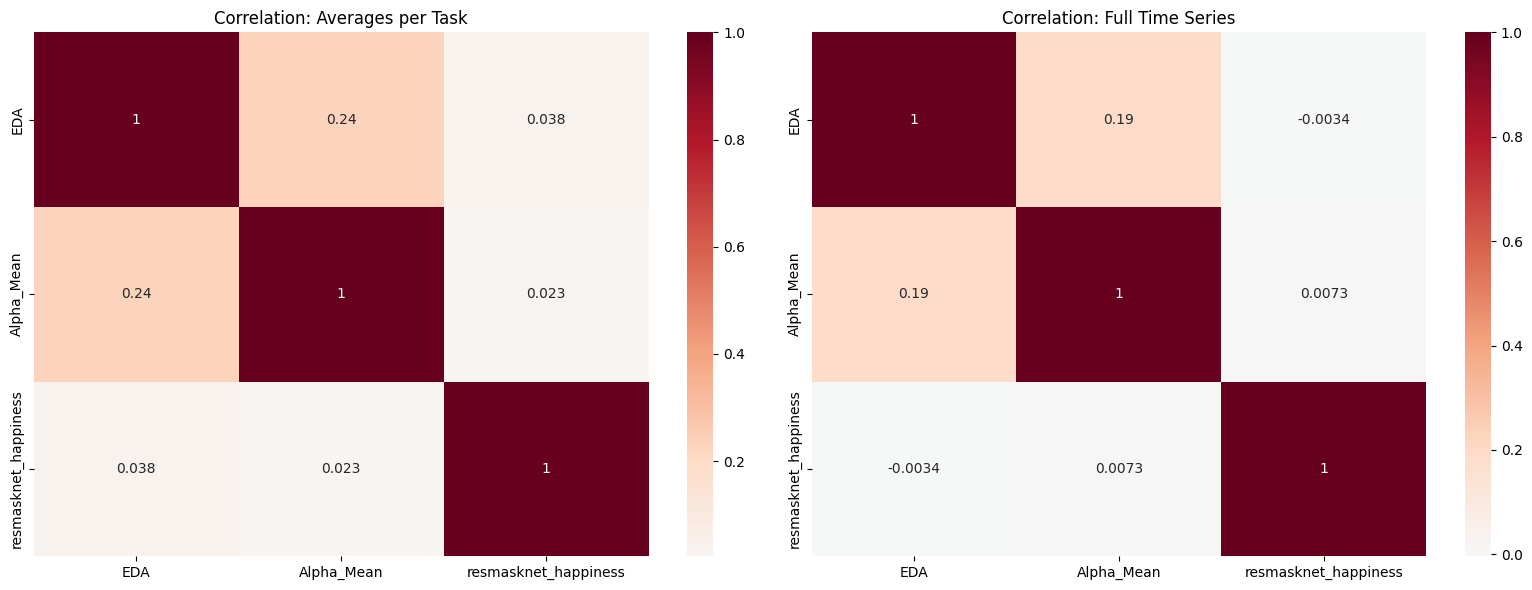

In [331]:
# 1. Create a combined Alpha feature if not already present
df['Alpha_Mean'] = df[['Alpha_TP9', 'Alpha_AF7', 'Alpha_AF8', 'Alpha_TP10']].mean(axis=1)

# Select the core modalities for comparison
cols = ['EDA', 'Alpha_Mean', 'resmasknet_happiness']

# (a) Averages per complete task (Inter-task level)
# This captures the "general state" of the person during the task
task_level_df = df.groupby(['Subject_ID', 'Task_Num'])[cols].mean().reset_index()
corr_task = task_level_df[cols].corr()

# (b) Full time series (Moment-to-moment level)
# This captures the raw alignment (which we know is asynchronous)
corr_timeseries = df[cols].corr()

# Plotting Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_task, annot=True, cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title("Correlation: Averages per Task")

sns.heatmap(corr_timeseries, annot=True, cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title("Correlation: Full Time Series")

plt.tight_layout()
plt.show()

With the per task correlations on the left and the full time-series correlations on the right, we can see that the correlations between the signals are slightly higher when using the per task data. This suggests that the signals are more closely related during the same task, which might mean that the latencies are more present when looking at all the data.

# Failed approach

When trying to look at the lagged correlations for the signals, we didn't initially group the records by task and found very little correlation between the signals. So much so that when finding the optimal lag, it would determine that the lag between EEG and EDA was over 20 seconds.

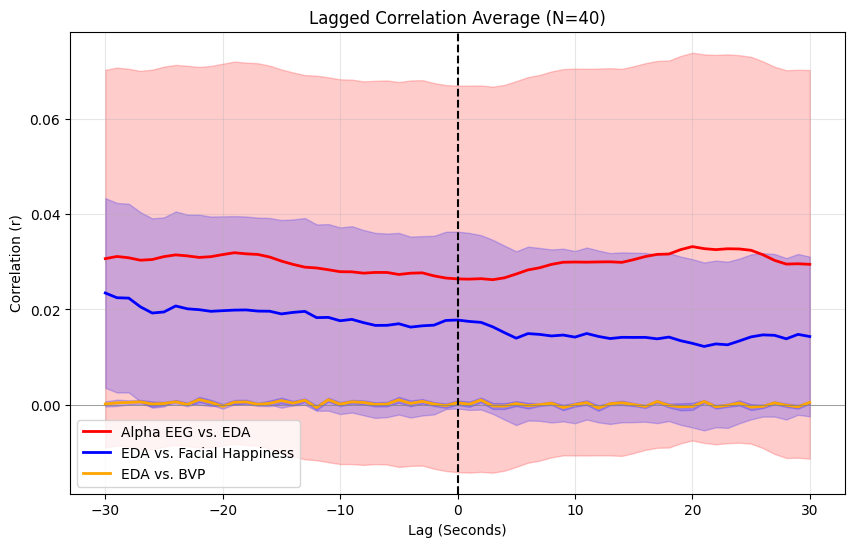

Optimal Lag (Alpha vs EDA): 20s: r=0.03316764136049852
Optimal Lag (EDA vs Happiness): -30s: r r=0.023449729663747847
Optimal Lag (EDA vs BVP): -22s: r=0.0011340582659978764


In [336]:
# 1. Prepare data
df['Alpha_Mean'] = df[['Alpha_TP9', 'Alpha_AF7', 'Alpha_AF8', 'Alpha_TP10']].mean(axis=1)
subjects = df['Subject_ID'].unique()
max_lag = 30  # Increased lag to see the full EDA curve
lags = np.arange(-max_lag, max_lag + 1)

# Containers for results
all_corrs_ae = []
all_corrs_eh = []
all_corrs_eb = []

# 2. Iterate through all subjects
for sub_id in subjects:
    sub_df = df[df['Subject_ID'] == sub_id].copy()
    
    # Calculate Alpha vs EDA
    corrs_ae = [sub_df['Alpha_Mean'].corr(sub_df['EDA'].shift(-lag)) for lag in lags]
    # Calculate EDA vs Facial Happiness
    corrs_eh = [sub_df['EDA'].corr(sub_df['resmasknet_happiness'].shift(-lag)) for lag in lags]
    # Calculate EDA vs BVP
    corrs_eb = [sub_df['EDA'].corr(sub_df['BVP'].shift(-lag)) for lag in lags]
    
    # Only add if there are no NaNs (some subjects might have missing facial data)
    if not np.isnan(corrs_ae).any():
        all_corrs_ae.append(corrs_ae)
    if not np.isnan(corrs_eh).any():
        all_corrs_eh.append(corrs_eh)
    if not np.isnan(corrs_eb).any():
        all_corrs_eb.append(corrs_eb)

# 3. Calculate Means and Standard Errors
mean_ae = np.mean(all_corrs_ae, axis=0)
std_ae = np.std(all_corrs_ae, axis=0) / np.sqrt(len(all_corrs_ae))

mean_eh = np.mean(all_corrs_eh, axis=0)
std_eh = np.std(all_corrs_eh, axis=0) / np.sqrt(len(all_corrs_eh))

mean_eb = np.mean(all_corrs_eb, axis=0)
std_eb = np.std(all_corrs_eb, axis=0) / np.sqrt(len(all_corrs_eb))

# 4. Plotting the single summary graph
plt.figure(figsize=(10, 6))

# Plot Alpha -> EDA
plt.plot(lags, mean_ae, label='Alpha EEG vs. EDA', color='red', linewidth=2)
plt.fill_between(lags, mean_ae - std_ae, mean_ae + std_ae, color='red', alpha=0.2)

# Plot EDA -> Happiness
plt.plot(lags, mean_eh, label='EDA vs. Facial Happiness', color='blue', linewidth=2)
plt.fill_between(lags, mean_eh - std_eh, mean_eh + std_eh, color='blue', alpha=0.2)

# Plot EDA -> BVP
plt.plot(lags, mean_eb, label='EDA vs. BVP', color='orange', linewidth=2)
plt.fill_between(lags, mean_eb - std_eb, mean_eb + std_eb, color='blue', alpha=0.2)

# UI Elements
plt.axvline(0, color='black', linestyle='--')
plt.axhline(0, color='gray', linewidth=0.5)
plt.title(f'Lagged Correlation Average (N={len(all_corrs_ae)})')
plt.xlabel('Lag (Seconds)')
plt.ylabel('Correlation (r)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Find the global optimal lags
opt_ae = lags[np.argmax(np.abs(mean_ae))]
opt_eh = lags[np.argmax(np.abs(mean_eh))]
opt_eb = lags[np.argmax(np.abs(mean_eb))]
print(f"Optimal Lag (Alpha vs EDA): {opt_ae}s: r={mean_ae[np.argmax(np.abs(mean_ae))]}")
print(f"Optimal Lag (EDA vs Happiness): {opt_eh}s: r r={mean_eh[np.argmax(np.abs(mean_eh))]}")
print(f"Optimal Lag (EDA vs BVP): {opt_eb}s: r={mean_eb[np.argmax(np.abs(mean_eb))]}")

# Discussion

## Main findings
- **Optimal lag between EDA and EEG:** According to the data in the dataset, the optimal lag is 10 seconds, where the maximum correlation of r=-0.15 is obtained. This negative correlation also indicates that Alpha brainwaves tend to go down when EDA readings go up.
- **Temporal asynchrony after stimulus:** After math and video tasks, we can gather that EDA takes usually around 5 seconds to peak, while the probability for a happiness emotion takes 3 to 10 seconds to peak as well. For the other part, EEG readings are really hard to discern at this slow of a sample rate.
- **Correlation per task vs full time-frame:** The correlation, especially the correlation of EDA and EEG, is slightly higher when separating the data per task.
- **High optimal lags:** The observed lags are much larger than anticipated, which indicates that the data being aligned to 1Hz introduced some sort of distortion that is hard to consider.

## Theoretical interpretation
- The EDA activation takes around 5 seconds after a stimulus, which is consistent with research from Dawson et al. (2007) regarding the electrodermal system.
- The EEG signals being quick and hard to track at such a small sample rate is described by Chakraborty et al. (2013), regarding the time to perception or time it takes for the brainwaves to reflect an external stimuli being perceived.

## Implications for methodological design
- The different modalities of the dataset contain significant lag that should be accounted for when comparing data across modalities. This means that careful consideration must be made when comparing changes that are expected to come from the same stimulus or initiating event.